In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

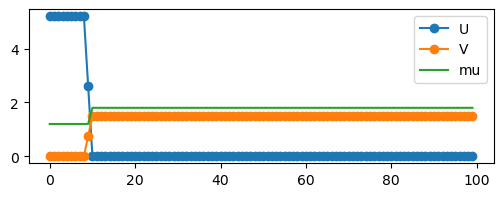

In [ ]:
widthN = 10
widthP = 90
X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.001

muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[:widthN:] = muN
mu[widthN:] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U0/2

V0 = 2 * t
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN-1] = V0/2 

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()

In [4]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.01, -0.01, 0.01j, -0.01j], 
                F0_init=0.1)

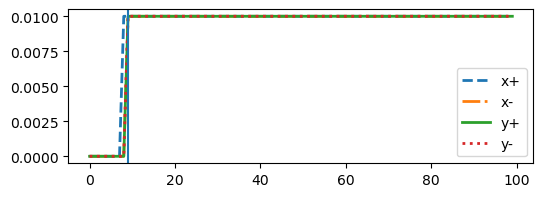

In [5]:
plt.figure(figsize=(6,2))
if U is not None:
    # plt.plot(H.F0, label="F0")
# if V is not None:
#     plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
#     plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
#     plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
#     plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
# if V_prime is not None:
    plt.plot(np.abs(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.abs(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.abs(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.abs(H.F_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)

In [6]:
bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=100, verbose=True, temperature=T)
F, Fuu, Fdd = H.get_correlations()
F0 = H.F0

F0:
Absolute error: 0.27982496570414056
Relative error: 58884938194.04402
Average old: (0.01+0j)
Average: (0.020663178249840177+0j)
F_xplus:
Absolute error: 0.09171879702806422
Relative error: 80849177657.14505
Average old: (0.009191919191919192+0j)
Average: (0.00629086350355806+0j)
F_xmin:
Absolute error: 0.09675713283731248
Relative error: 90023858770.28496
Average old: (-0.00909090909090909+0j)
Average: (-0.013113961073057291+0j)
F_yplus:
Absolute error: 0.1073093142382204
Relative error: 99710099011.75111
Average old: 0.009099999999999999j
Average: (-0.004505809710455132+0.009962309844799545j)
F_ymin:
Absolute error: 0.1073093142382204
Relative error: 99710099011.75111
Average old: -0.009099999999999999j
Average: (-0.004505809710455132-0.009962309844799545j)
Fuu_xplus:
Absolute error: 4.0006296303900114e-17
Relative error: 4.000629630390012e-05
Average old: 0j
Average: (4.0532675498513616e-19+0j)
Fuu_xmin:
Absolute error: 3.6648646387799035e-17
Relative error: 3.664864638779903e-05

T=0.001t


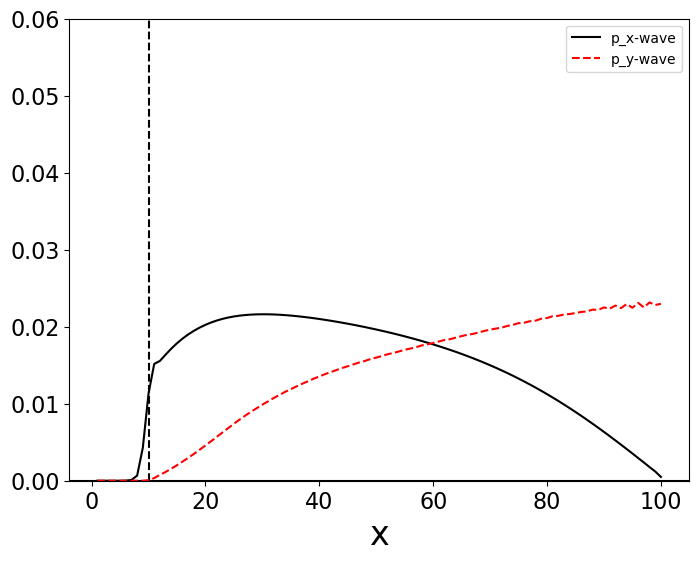

[3.87962698e-01 3.69362268e-01 3.69709103e-01 3.69606722e-01
 3.69591795e-01 3.69549669e-01 3.69319043e-01 3.67453620e-01
 3.54360042e-01 2.02633658e-01 6.59919038e-02 4.46408842e-02
 3.40210069e-02 2.79008855e-02 2.41837855e-02 2.06987884e-02
 1.88174855e-02 1.63764177e-02 1.51982507e-02 1.33476066e-02
 1.24591285e-02 1.10080453e-02 1.02422869e-02 9.10831484e-03
 8.43033154e-03 7.59204484e-03 7.01686740e-03 6.43327242e-03
 5.92951516e-03 5.49328616e-03 4.99591630e-03 4.63520920e-03
 4.17433476e-03 3.92500752e-03 3.55785092e-03 3.38526542e-03
 3.04408356e-03 2.86519174e-03 2.55873149e-03 2.43004505e-03
 2.21227747e-03 2.09725250e-03 1.90530285e-03 1.78199313e-03
 1.65940178e-03 1.54590596e-03 1.45078337e-03 1.31290737e-03
 1.27225431e-03 1.14167496e-03 1.12870647e-03 9.81700253e-04
 1.00943350e-03 8.62842274e-04 8.90452601e-04 7.59720354e-04
 8.00169945e-04 6.81543998e-04 7.11034780e-04 6.34732595e-04
 6.22906722e-04 5.96633000e-04 5.49576686e-04 5.72609594e-04
 4.83369578e-04 5.615012

In [11]:
print(f"T={T}t")
x = np.arange(1, widthN + widthP+1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.axhline(0, color = 'black')
axs.axvline(widthN, color='black', linestyle='--')
# axs.plot(x, np.real(F0), label='onsite')
# axs.plot(x, np.real(F.swave), color='green', label="s-wave")
# axs.plot(x, np.real(F.dwave), color='blue', label="d-wave")
# axs.plot(x, np.real(Fuu.px), color='orange', label="uu:p_x-wave")
axs.plot(x, np.real(F.px), color='black', label="p_x-wave")
axs.plot(x, np.imag(F.py), "--", color='red', label="p_y-wave")

axs.set_xlabel(r"x", fontsize=24)
# axs.set_yticks([])
# axs.set_xlim(1, 50)
axs.set_ylim(0, 0.06)
axs.tick_params(labelsize=16)
plt.legend()
plt.savefig('../figures/SP.svg')
plt.show()
print(np.real(F0))

In [7]:
T_list = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.20 + 1e-12, 0.001),
]) #
print(len(T_list))

200
